# Customer Segmentation for an Online Retail Business
## RFM Analysis and K-Means Clustering

**Dataset:** UCI Online Retail Dataset

**Machine Learning Task:** Unsupervised Learning / Customer Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percentage
})

missing_table.sort_values('Missing Values', ascending=False)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
print("Number of transactions:", df['InvoiceNo'].nunique())
print("Number of products:", df['StockCode'].nunique())
print("Number of customers:", df['CustomerID'].nunique())
print("Number of countries:", df['Country'].nunique())

Number of transactions: 25900
Number of products: 4070
Number of customers: 4372
Number of countries: 38


In [ ]:
df['Country'].value_counts().head(15)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


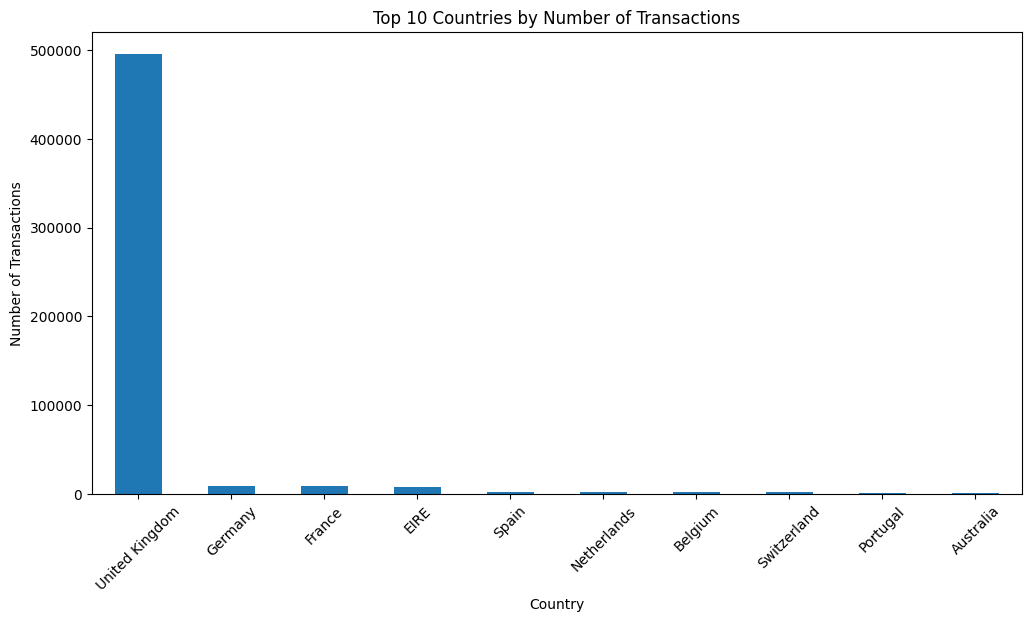

In [ ]:
plt.figure(figsize=(12,6))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

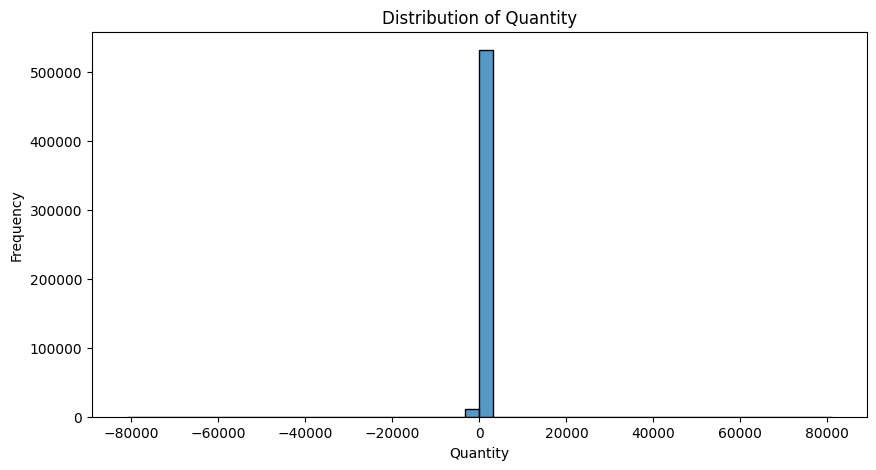

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Quantity'], bins=50)

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

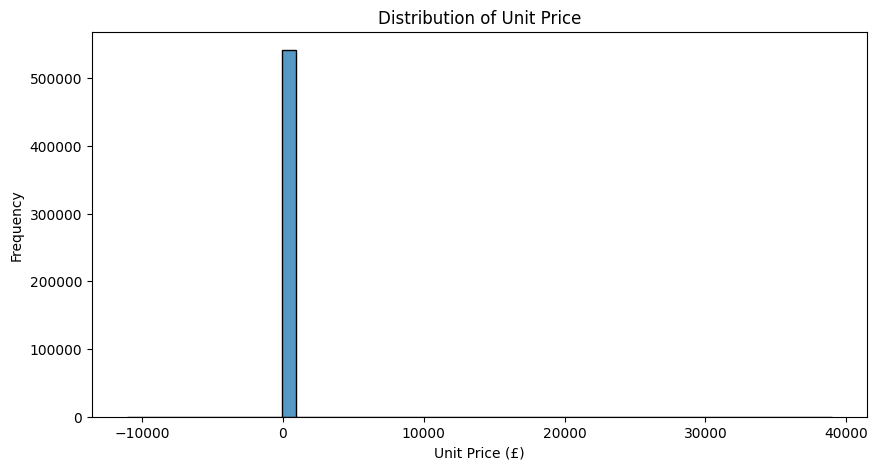

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['UnitPrice'], bins=50)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df_clean = df.copy()

print("Original rows:", len(df))
print("Working dataset rows:", len(df_clean))

Original rows: 541909
Working dataset rows: 541909


In [ ]:
df_clean = df_clean.dropna(subset=['CustomerID'])

print("Rows after removing missing CustomerID:")
print(len(df_clean))

Rows after removing missing CustomerID:
406829


In [ ]:
df_clean = df_clean.drop_duplicates()

print("Rows after removing duplicates:")
print(len(df_clean))

Rows after removing duplicates:
401604


In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(df_clean['InvoiceDate'].dtype)

datetime64[ns]


In [ ]:
cancellations = df_clean[
    df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Cancellation transactions:", len(cancellations))

Cancellation transactions: 8872


In [ ]:
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

print("Rows after removing cancellations:", len(df_clean))

Rows after removing cancellations: 392732


In [ ]:
print("Negative quantities:", (df_clean['Quantity'] < 0).sum())

Negative quantities: 0


In [ ]:
df_clean = df_clean[df_clean['Quantity'] > 0]

print("Rows remaining:", len(df_clean))

Rows remaining: 392732


In [ ]:
print("Zero/negative prices:", (df_clean['UnitPrice'] <= 0).sum())

Zero/negative prices: 40


In [ ]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print("Rows remaining:", len(df_clean))

Rows remaining: 392692


In [ ]:
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
analysis_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [ ]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


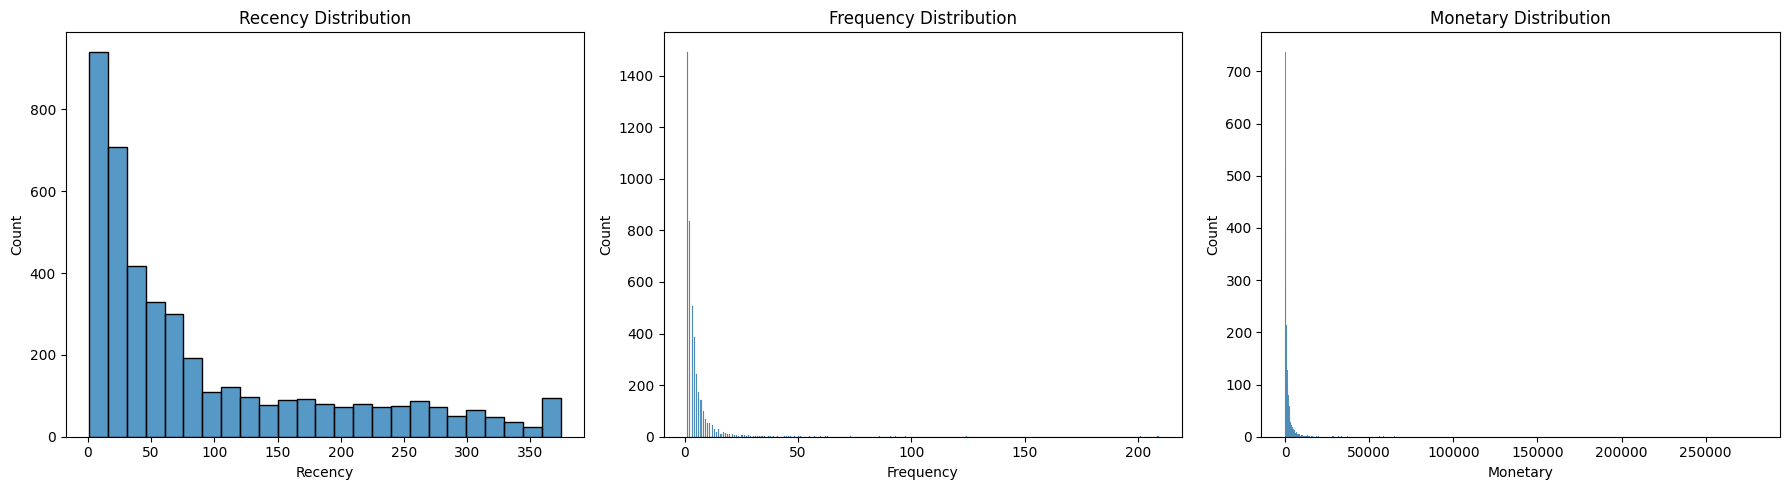

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

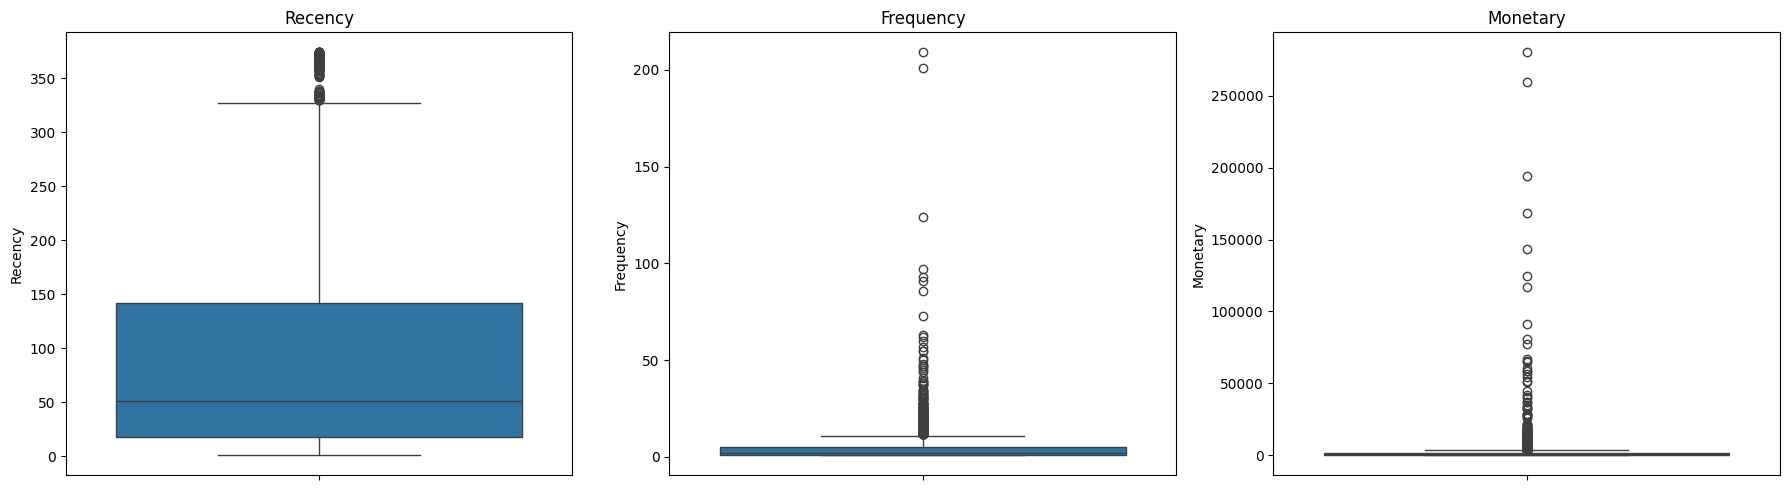

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(y=rfm['Recency'], ax=axes[0])
axes[0].set_title('Recency')

sns.boxplot(y=rfm['Frequency'], ax=axes[1])
axes[1].set_title('Frequency')

sns.boxplot(y=rfm['Monetary'], ax=axes[2])
axes[2].set_title('Monetary')

plt.tight_layout()
plt.show()

In [ ]:
features = ['Recency', 'Frequency', 'Monetary']

X = rfm[features].copy()

X.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=X.index
)

X_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.55473084 0.30252713]
Total explained variance:
0.8572579763919153


In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=X_scaled.index
)

pca_df.head()

,PC1,PC2
CustomerID,,
12346.0,4.107554,5.439993
12347.0,0.743044,-0.670756
12348.0,0.025230,-0.174675
12349.0,-0.027491,-0.734603
12350.0,-1.235593,1.834685


In [ ]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

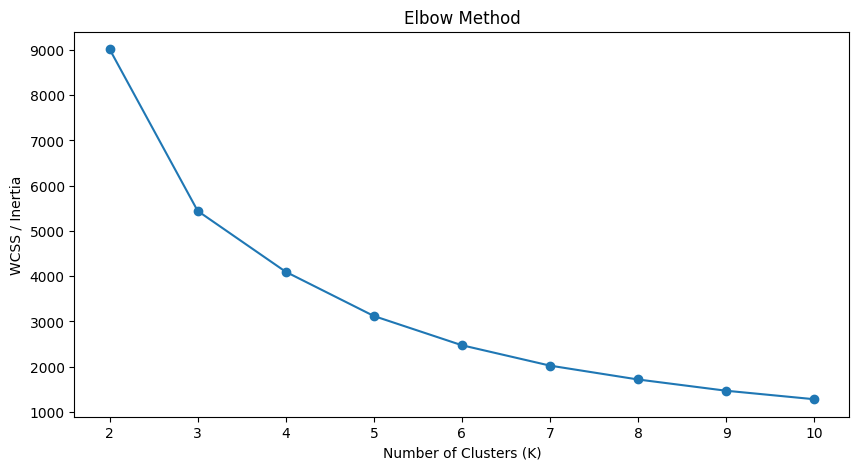

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(list(K_range))
plt.show()

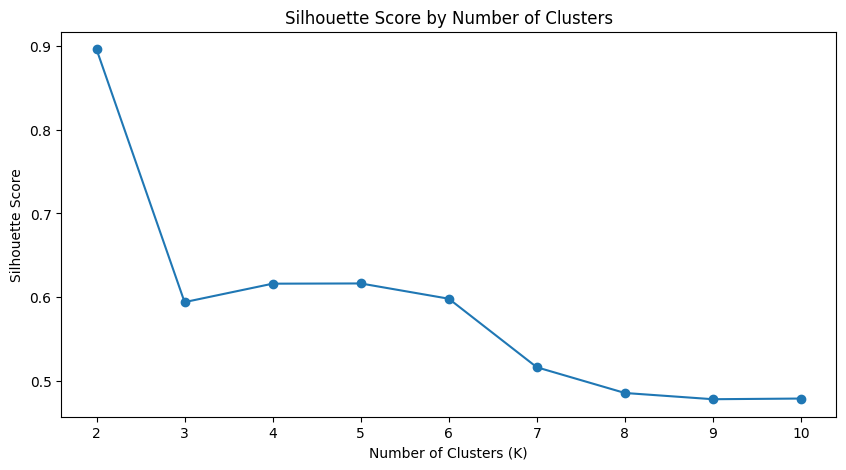

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range))
plt.show()

In [ ]:
results = pd.DataFrame({
    'K': list(K_range),
    'WCSS': inertia,
    'Silhouette Score': silhouette_scores
})

results

,K,WCSS,Silhouette Score
0,2,9014.566280,0.895825
1,3,5441.323587,0.594223
2,4,4096.300211,0.616228
3,5,3119.789860,0.616500
4,6,2473.793364,0.598289
5,7,2023.586627,0.516532
6,8,1717.011043,0.485874
7,9,1468.787102,0.478438
8,10,1281.048051,0.479244


In [ ]:
best_k = results.loc[
    results['Silhouette Score'].idxmax(),
    'K'
]

print("Best K based on Silhouette Score:", best_k)

Best K based on Silhouette Score: 2


In [ ]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = final_kmeans.fit_predict(X_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,0


In [ ]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,4312
1,26


In [ ]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
})

cluster_profile = cluster_profile.rename(
    columns={'Cluster': 'Customer Count'}
)

cluster_profile

,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,93.057978,3.897263,1543.536842,4312
1,6.038462,66.423077,85826.078077,26


In [ ]:
high_value_customers = rfm[rfm['Cluster'] == 1].sort_values(
    'Monetary',
    ascending=False
)

high_value_customers

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
14646.0,2,73,280206.02,1
18102.0,1,60,259657.30,1
17450.0,8,46,194390.79,1
16446.0,1,2,168472.50,1
14911.0,1,201,143711.17,1
12415.0,24,21,124914.53,1
14156.0,10,55,117210.08,1
17511.0,3,31,91062.38,1
16029.0,39,63,80850.84,1


In [ ]:
high_value_customers[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,26.000000,26.000000,26.000000
mean,6.038462,66.423077,85826.078077
std,8.599911,49.129358,70834.064003
min,1.000000,2.000000,11189.910000
25%,1.000000,44.250000,37995.347500
50%,3.500000,53.000000,59697.415000
75%,6.250000,82.750000,110673.155000
max,39.000000,209.000000,280206.020000


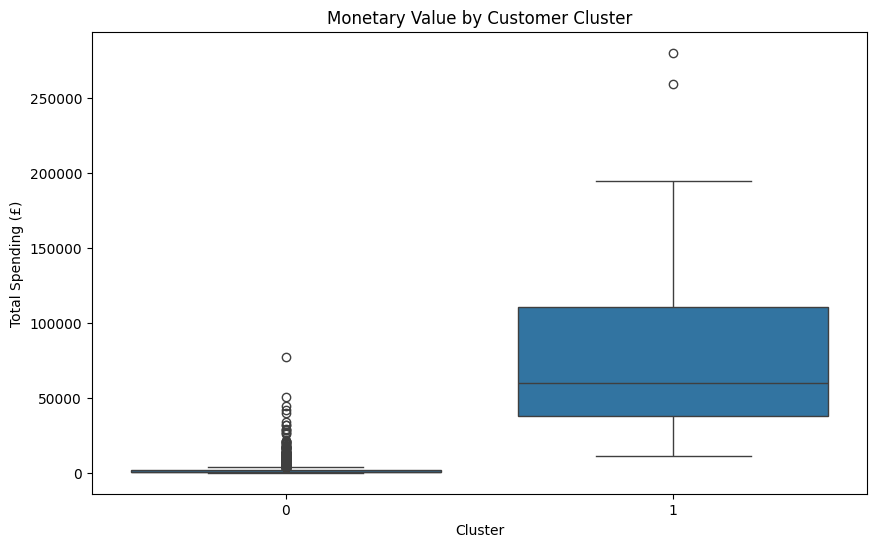

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=rfm,
    x='Cluster',
    y='Monetary'
)

plt.title('Monetary Value by Customer Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Spending (£)')

plt.show()

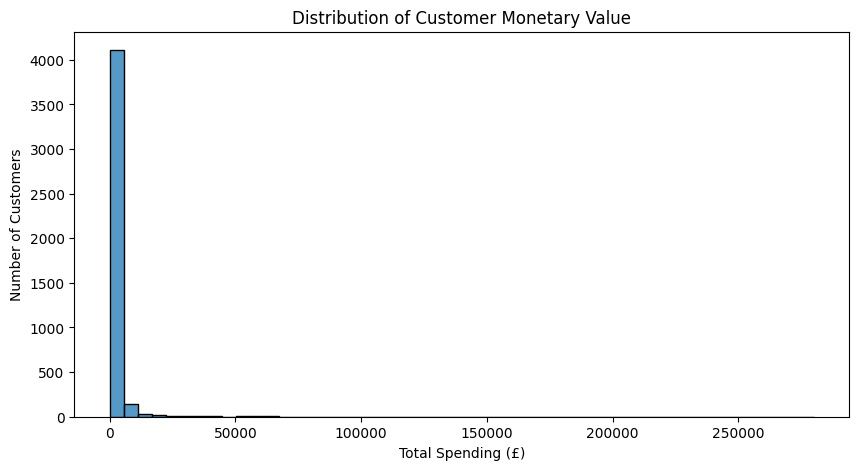

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Monetary'], bins=50)

plt.title('Distribution of Customer Monetary Value')
plt.xlabel('Total Spending (£)')
plt.ylabel('Number of Customers')

plt.show()

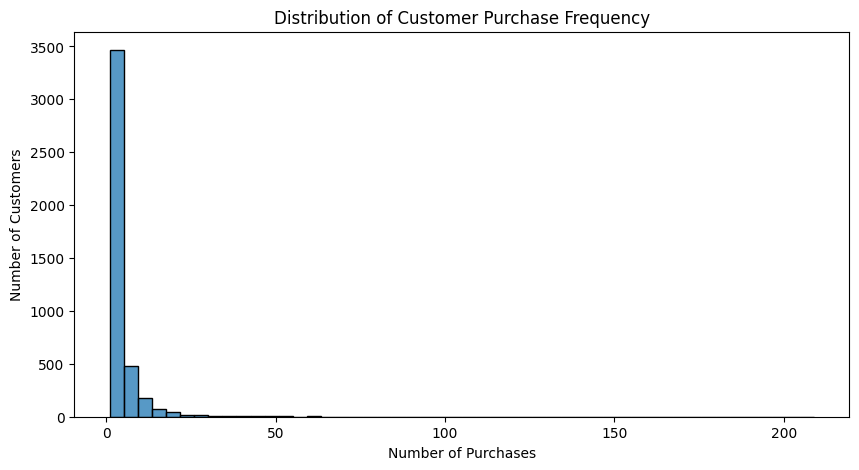

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Frequency'], bins=50)

plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')

plt.show()

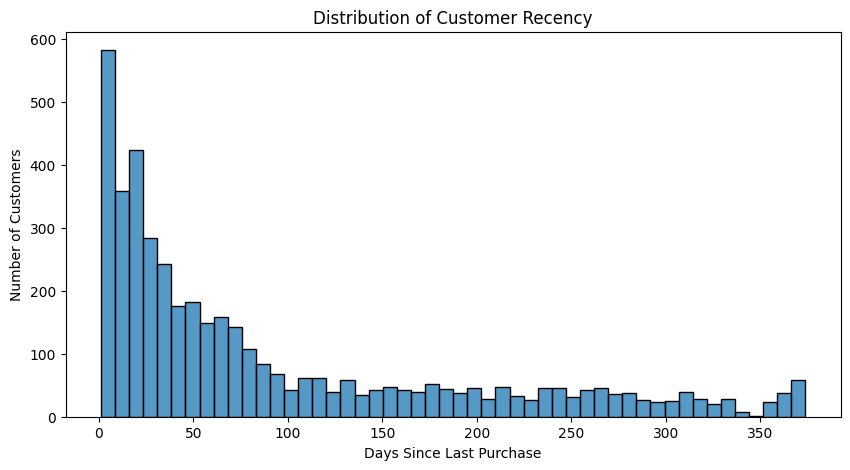

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=50)

plt.title('Distribution of Customer Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
high_value_customers = rfm[rfm['Cluster'] == 1].sort_values(
    'Monetary',
    ascending=False
)

high_value_customers

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
14646.0,2,73,280206.02,1
18102.0,1,60,259657.30,1
17450.0,8,46,194390.79,1
16446.0,1,2,168472.50,1
14911.0,1,201,143711.17,1
12415.0,24,21,124914.53,1
14156.0,10,55,117210.08,1
17511.0,3,31,91062.38,1
16029.0,39,63,80850.84,1


In [ ]:
high_value_customers[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,26.000000,26.000000,26.000000
mean,6.038462,66.423077,85826.078077
std,8.599911,49.129358,70834.064003
min,1.000000,2.000000,11189.910000
25%,1.000000,44.250000,37995.347500
50%,3.500000,53.000000,59697.415000
75%,6.250000,82.750000,110673.155000
max,39.000000,209.000000,280206.020000


In [ ]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg([
    'min',
    'max',
    'mean',
    'median'
])

Recency                        Frequency                         \
            min  max       mean median       min  max       mean median   
Cluster                                                                   
0             1  374  93.057978   51.0         1   55   3.897263    2.0   
1             1   39   6.038462    3.5         2  209  66.423077   53.0   

         Monetary                                      
              min        max          mean     median  
Cluster                                                
0            3.75   77183.60   1543.536842    662.565  
1        11189.91  280206.02  85826.078077  59697.415

In [ ]:
print("Monetary:")
print(rfm['Monetary'].describe())

print("\nFrequency:")
print(rfm['Frequency'].describe())

print("\nRecency:")
print(rfm['Recency'].describe())

Monetary:
count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Monetary, dtype: float64

Frequency:
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Frequency, dtype: float64

Recency:
count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64


In [ ]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [ ]:
scaler_log = StandardScaler()

X_log_scaled = scaler_log.fit_transform(rfm_log)

X_log_scaled = pd.DataFrame(
    X_log_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm_log.index
)

X_log_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514


In [ ]:
inertia_log = []
silhouette_scores_log = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_log_scaled)

    inertia_log.append(kmeans.inertia_)
    silhouette_scores_log.append(
        silhouette_score(X_log_scaled, labels)
    )

results_log = pd.DataFrame({
    'K': list(K_range),
    'WCSS': inertia_log,
    'Silhouette Score': silhouette_scores_log
})

results_log

,K,WCSS,Silhouette Score
0,2,6483.589425,0.432827
1,3,4869.488629,0.336517
2,4,3939.049382,0.337517
3,5,3296.708708,0.316200
4,6,2855.764068,0.312409
5,7,2548.820245,0.309186
6,8,2336.341054,0.303275
7,9,2156.005673,0.281085
8,10,2005.746236,0.276659


In [ ]:
best_k_log = results_log.loc[
    results_log['Silhouette Score'].idxmax(),
    'K'
]

print("Best K after log transformation:", best_k_log)

Best K after log transformation: 2


In [ ]:
final_kmeans_log = KMeans(
    n_clusters=int(best_k_log),
    random_state=42,
    n_init=10
)

rfm['Cluster_Log'] = final_kmeans_log.fit_predict(X_log_scaled)

print(rfm['Cluster_Log'].value_counts().sort_index())

Cluster_Log
0    2672
1    1666
Name: count, dtype: int64


In [ ]:
cluster_profile_log = rfm.groupby('Cluster_Log').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_Log': 'count'
})

cluster_profile_log = cluster_profile_log.rename(
    columns={'Cluster_Log': 'Customer Count'}
)

cluster_profile_log

,Recency,Frequency,Monetary,Customer Count
Cluster_Log,,,,
0,134.091317,1.671033,495.594945,2672
1,25.888956,8.443577,4539.603362,1666


In [ ]:
final_silhouette_log = silhouette_score(
    X_log_scaled,
    rfm['Cluster_Log']
)

final_db_log = davies_bouldin_score(
    X_log_scaled,
    rfm['Cluster_Log']
)

print("Final Silhouette Score:", round(final_silhouette_log, 4))
print("Final Davies-Bouldin Index:", round(final_db_log, 4))

Final Silhouette Score: 0.4328
Final Davies-Bouldin Index: 0.8925


In [ ]:
pca_final = PCA(n_components=2)

X_pca_final = pca_final.fit_transform(X_log_scaled)

print("Explained variance ratio:")
print(pca_final.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca_final.explained_variance_ratio_.sum())

Explained variance ratio:
[0.75078634 0.18786648]

Total explained variance:
0.9386528181989533


In [ ]:
cluster_summary = rfm.groupby('Cluster_Log').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'Cluster_Log': 'count'
})

cluster_summary

Recency        Frequency            Monetary            \
                   mean median      mean median         mean    median   
Cluster_Log                                                              
0            134.091317   96.0  1.671033    1.0   495.594945   363.075   
1             25.888956   16.0  8.443577    6.0  4539.603362  2061.075   

            Cluster_Log  
                  count  
Cluster_Log              
0                  2672  
1                  1666

In [ ]:
cluster_means = rfm.groupby('Cluster_Log')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

print("Cluster means:")
print(cluster_means)

print("\nPercentage difference between clusters:")

recency_diff = (
    (cluster_means.loc[0, 'Recency'] - cluster_means.loc[1, 'Recency'])
    / cluster_means.loc[0, 'Recency']
) * 100

frequency_diff = (
    (cluster_means.loc[1, 'Frequency'] - cluster_means.loc[0, 'Frequency'])
    / cluster_means.loc[0, 'Frequency']
) * 100

monetary_diff = (
    (cluster_means.loc[1, 'Monetary'] - cluster_means.loc[0, 'Monetary'])
    / cluster_means.loc[0, 'Monetary']
) * 100

print(f"Recency improvement: {recency_diff:.2f}%")
print(f"Frequency increase: {frequency_diff:.2f}%")
print(f"Monetary increase: {monetary_diff:.2f}%")

Cluster means:
                Recency  Frequency     Monetary
Cluster_Log                                    
0            134.091317   1.671033   495.594945
1             25.888956   8.443577  4539.603362

Percentage difference between clusters:
Recency improvement: 80.69%
Frequency increase: 405.29%
Monetary increase: 815.99%


In [ ]:
# Customer percentage
customer_share = (
    rfm['Cluster_Log']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Customer share (%):")
print(customer_share)

# Total monetary value by cluster
revenue_by_cluster = rfm.groupby('Cluster_Log')['Monetary'].sum()

print("\nTotal monetary value by cluster:")
print(revenue_by_cluster)

# Revenue percentage
revenue_share = (
    revenue_by_cluster / revenue_by_cluster.sum()
) * 100

print("\nRevenue share (%):")
print(revenue_share)

Customer share (%):
Cluster_Log
0    61.595205
1    38.404795
Name: proportion, dtype: float64

Total monetary value by cluster:
Cluster_Log
0    1324229.693
1    7562979.201
Name: Monetary, dtype: float64

Revenue share (%):
Cluster_Log
0    14.9004
1    85.0996
Name: Monetary, dtype: float64


In [ ]:
print("Final model:")
print("Number of clusters:", best_k_log)
print("Silhouette Score:", round(final_silhouette_log, 4))
print("Davies-Bouldin Index:", round(final_db_log, 4))
print("PCA variance retained:", round(pca_final.explained_variance_ratio_.sum() * 100, 2), "%")

Final model:
Number of clusters: 2
Silhouette Score: 0.4328
Davies-Bouldin Index: 0.8925
PCA variance retained: 93.87 %


In [ ]:
print("Features used for clustering:")
print(X_log_scaled.columns.tolist())

Features used for clustering:
['Recency', 'Frequency', 'Monetary']


In [ ]:
print("Number of customers:", len(rfm))
print("Number of features:", X_log_scaled.shape[1])

Number of customers: 4338
Number of features: 3


In [ ]:
print("Missing values:")
print(rfm[['Recency', 'Frequency', 'Monetary']].isnull().sum())

Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [ ]:
print("Duplicate customer records:", rfm.index.duplicated().sum())

Duplicate customer records: 0


In [ ]:
print("Maximum original Monetary:", rfm['Monetary'].max())
print("Maximum log-transformed Monetary:", rfm_log['Monetary'].max())

print("\nMaximum original Frequency:", rfm['Frequency'].max())
print("Maximum log-transformed Frequency:", rfm_log['Frequency'].max())

Maximum original Monetary: 280206.02
Maximum log-transformed Monetary: 12.5432839661044

Maximum original Frequency: 209
Maximum log-transformed Frequency: 5.3471075307174685


In [ ]:
seeds = [1, 10, 42, 100, 2026]

stability_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=2,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X_log_scaled)

    score = silhouette_score(X_log_scaled, labels)

    stability_results.append({
        'Random Seed': seed,
        'Silhouette Score': score,
        'Cluster 0': (labels == 0).sum(),
        'Cluster 1': (labels == 1).sum()
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,Random Seed,Silhouette Score,Cluster 0,Cluster 1
0,1,0.432788,2671,1667
1,10,0.432884,1663,2675
2,42,0.432827,2672,1666
3,100,0.432788,2671,1667
4,2026,0.432788,2671,1667


In [ ]:
customer_country = df.groupby('CustomerID')['Country'].first()

rfm['Country'] = rfm.index.map(customer_country)

rfm[['Country', 'Cluster_Log']].head()

,Country,Cluster_Log
CustomerID,,
12346.0,United Kingdom,1
12347.0,Iceland,1
12348.0,Finland,1
12349.0,Italy,0
12350.0,Norway,0


In [ ]:
country_cluster = pd.crosstab(
    rfm['Country'],
    rfm['Cluster_Log'],
    normalize='index'
) * 100

country_cluster.round(2)

Cluster_Log,0,1
Country,,
Australia,55.56,44.44
Austria,66.67,33.33
Bahrain,100.00,0.00
Belgium,45.83,54.17
Brazil,100.00,0.00
Canada,100.00,0.00
Channel Islands,66.67,33.33
Cyprus,57.14,42.86
Czech Republic,100.00,0.00


In [ ]:
country_counts = rfm['Country'].value_counts()

major_countries = country_counts[country_counts >= 20].index

country_analysis = (
    rfm[rfm['Country'].isin(major_countries)]
    .groupby(['Country', 'Cluster_Log'])
    .size()
    .unstack(fill_value=0)
)

country_analysis

Cluster_Log,0,1
Country,,
Belgium,11,13
France,45,42
Germany,49,45
Spain,18,10
Switzerland,13,7
United Kingdom,2428,1492


In [ ]:
country_analysis_percent = (
    country_analysis
    .div(country_analysis.sum(axis=1), axis=0)
    * 100
)

country_analysis_percent.round(2)

Cluster_Log,0,1
Country,,
Belgium,45.83,54.17
France,51.72,48.28
Germany,52.13,47.87
Spain,64.29,35.71
Switzerland,65.00,35.00
United Kingdom,61.94,38.06


In [ ]:
# Calculate standardized cluster centers
cluster_centers = pd.DataFrame(
    final_kmeans_log.cluster_centers_,
    columns=['Recency', 'Frequency', 'Monetary']
)

print("Cluster centers in standardized log-transformed space:")
cluster_centers

Cluster centers in standardized log-transformed space:


,Recency,Frequency,Monetary
0,0.502805,-0.603097,-0.566714
1,-0.807205,0.968215,0.909806


In [ ]:
# Calculate absolute difference between cluster centers
feature_separation = abs(
    cluster_centers.loc[0] - cluster_centers.loc[1]
)

feature_separation = feature_separation.sort_values(
    ascending=False
)

print("Feature separation:")
print(feature_separation)

Feature separation:
Frequency    1.571312
Monetary     1.476520
Recency      1.310010
dtype: float64


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Unique customers:", df['CustomerID'].nunique())
print("Unique products:", df['StockCode'].nunique())
print("Unique countries:", df['Country'].nunique())
print("Unique invoices:", df['InvoiceNo'].nunique())

Unique customers: 4372
Unique products: 4070
Unique countries: 38
Unique invoices: 25900


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Earliest transaction:", df['InvoiceDate'].min())
print("Latest transaction:", df['InvoiceDate'].max())

Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00


In [ ]:
data_dictionary = pd.DataFrame({
    'Variable': [
        'InvoiceNo',
        'StockCode',
        'Description',
        'Quantity',
        'InvoiceDate',
        'UnitPrice',
        'CustomerID',
        'Country'
    ],
    'Data Type': [
        'Categorical',
        'Categorical',
        'Text',
        'Numeric',
        'DateTime',
        'Numeric',
        'Numeric/Identifier',
        'Categorical'
    ],
    'Description': [
        'Unique identifier for each transaction or invoice',
        'Unique code identifying the product',
        'Text description of the product',
        'Number of units purchased in the transaction',
        'Date and time when the transaction occurred',
        'Price per unit of the product',
        'Unique identifier for each customer',
        'Country associated with the customer'
    ],
    'Role in Analysis': [
        'Used to calculate transaction frequency',
        'Used to identify unique products',
        'Used for product-level information',
        'Used to calculate monetary value',
        'Used to calculate recency',
        'Used with Quantity to calculate monetary value',
        'Used to aggregate transactions by customer',
        'Used for geographic bias analysis'
    ]
})

data_dictionary

,Variable,Data Type,Description,Role in Analysis
0,InvoiceNo,Categorical,Unique identifier for each transaction or invoice,Used to calculate transaction frequency
1,StockCode,Categorical,Unique code identifying the product,Used to identify unique products
2,Description,Text,Text description of the product,Used for product-level information
3,Quantity,Numeric,Number of units purchased in the transaction,Used to calculate monetary value
4,InvoiceDate,DateTime,Date and time when the transaction occurred,Used to calculate recency
5,UnitPrice,Numeric,Price per unit of the product,Used with Quantity to calculate monetary value
6,CustomerID,Numeric/Identifier,Unique identifier for each customer,Used to aggregate transactions by customer
7,Country,Categorical,Country associated with the customer,Used for geographic bias analysis


In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Total transaction value:")
print(df['TotalPrice'].sum())

print("\nAverage transaction value:")
print(df['TotalPrice'].mean())

Total transaction value:
9747747.933999998

Average transaction value:
17.98779487699964


In [ ]:
print("RFM features used in clustering:")
print()
print("Recency    = Days since customer's last purchase")
print("Frequency  = Number of unique invoices/purchases")
print("Monetary   = Total amount spent by the customer")

RFM features used in clustering:

Recency    = Days since customer's last purchase
Frequency  = Number of unique invoices/purchases
Monetary   = Total amount spent by the customer


In [ ]:
print("Original rows:", len(df))

print("\nNegative quantities:")
print((df['Quantity'] < 0).sum())

print("\nZero or negative unit prices:")
print((df['UnitPrice'] <= 0).sum())

print("\nMissing CustomerID:")
print(df['CustomerID'].isnull().sum())

print("\nMissing Description:")
print(df['Description'].isnull().sum())

Original rows: 541909

Negative quantities:
10624

Zero or negative unit prices:
2517

Missing CustomerID:
135080

Missing Description:
1454


In [ ]:
print("\nInvoices starting with C:")
print(df['InvoiceNo'].astype(str).str.startswith('C').sum())


Invoices starting with C:
9288


In [ ]:
print("RFM customers:", len(rfm))

print("\nRFM columns:")
print(rfm.columns.tolist())

print("\nRFM sample:")
print(rfm.head())

print("\nRFM minimum values:")
print(rfm[['Recency', 'Frequency', 'Monetary']].min())

RFM customers: 4338

RFM columns:
['Recency', 'Frequency', 'Monetary', 'Cluster', 'Cluster_Log', 'Country']

RFM sample:
            Recency  Frequency  Monetary  Cluster  Cluster_Log         Country
CustomerID                                                                    
12346.0         326          1  77183.60        0            1  United Kingdom
12347.0           2          7   4310.00        0            1         Iceland
12348.0          75          4   1797.24        0            1         Finland
12349.0          19          1   1757.55        0            0           Italy
12350.0         310          1    334.40        0            0          Norway

RFM minimum values:
Recency      1.00
Frequency    1.00
Monetary     3.75
dtype: float64
